In [2]:
import os
from getdist import loadMCSamples, MCSamples, plots
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib
%matplotlib inline


chain_root = "/home/weichen/cosmo_practice/chains/chains_kawas/hsc_lens_only_study"  
samples = loadMCSamples(
    chain_root,
    settings={"ignore_rows": 0.3}
)

print("# of weighted samples:", samples.weights.sum())
print("name of parameter:")
print(samples.getParamNames().list())

# of weighted samples: 384528.0
name of parameter:
['tau', 'ombh2', 'omch2', 'H0', 'ns', 'AIA', 'dm_0', 'dpz_0', 'logA', 'X1', 'X2', 'X3', 'b1', 'b2', 'b3', 'As', 'om_m', 'sigma8', 'S8_z_L1', 'S8_z_L2', 'S8_z_L3', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__test_hsc_lens.HSC_Lens']


In [3]:
p = samples.getParams()
S8 = p.sigma8 * np.sqrt(p.om_m / 0.3)

samples.addDerived(
    S8,
    name="S8",
    label="S_8"
)
samples.updateBaseStatistics()

In [4]:
params_to_report = [
    "om_m", "sigma8", "S8",
    "AIA", "dm_0", "dpz_0",
    "X1", "X2", "X3",
    "b1", "b2", "b3"
]
stats = samples.getMargeStats()
rows = []

for name in params_to_report:
    par = stats.parWithName(name)
    if par is None:
        print(f"{name} not in chain")
        continue

    interval68 = par.limits[0]
    rows.append({
        "parameter": name,
        "mean": par.mean,
        "std": par.err,
        "lower_68": interval68.lower,
        "upper_68": interval68.upper
    })
posterior_table = pd.DataFrame(rows)
display(posterior_table.round(5))

,parameter,mean,std,lower_68,upper_68
0,om_m,0.33626,0.04289,0.28975,0.37902
1,sigma8,0.70588,0.06272,0.63809,0.76268
2,S8,0.74278,0.04663,0.69350,0.78537
3,AIA,-0.04511,2.86017,-5.00000,5.00000
4,dm_0,0.00030,0.01009,-0.00984,0.01039
5,dpz_0,-0.05745,0.08708,-0.14320,0.02682
6,X1,1.09943,0.17394,0.92623,1.27229
7,X2,1.24091,0.13666,1.10574,1.37714
8,X3,1.17697,0.14499,1.02029,1.30328
9,b1,2.01700,0.37344,1.59827,2.27028


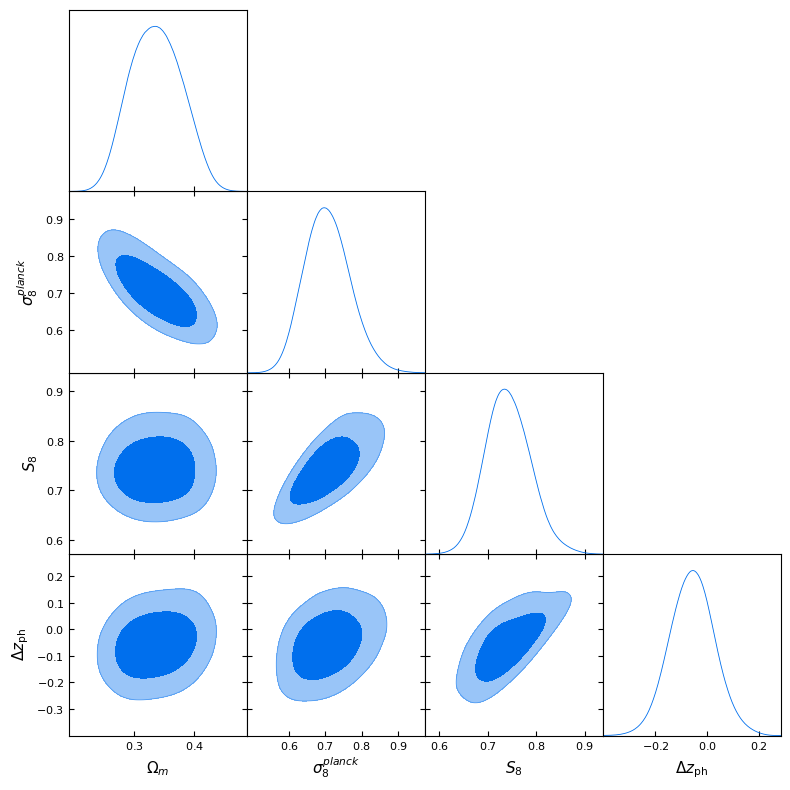

In [5]:
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False

g.triangle_plot(
    [samples],
    ["om_m", "sigma8", "S8", "dpz_0"],
    filled=True
)
g.export("tri_om_m.png")

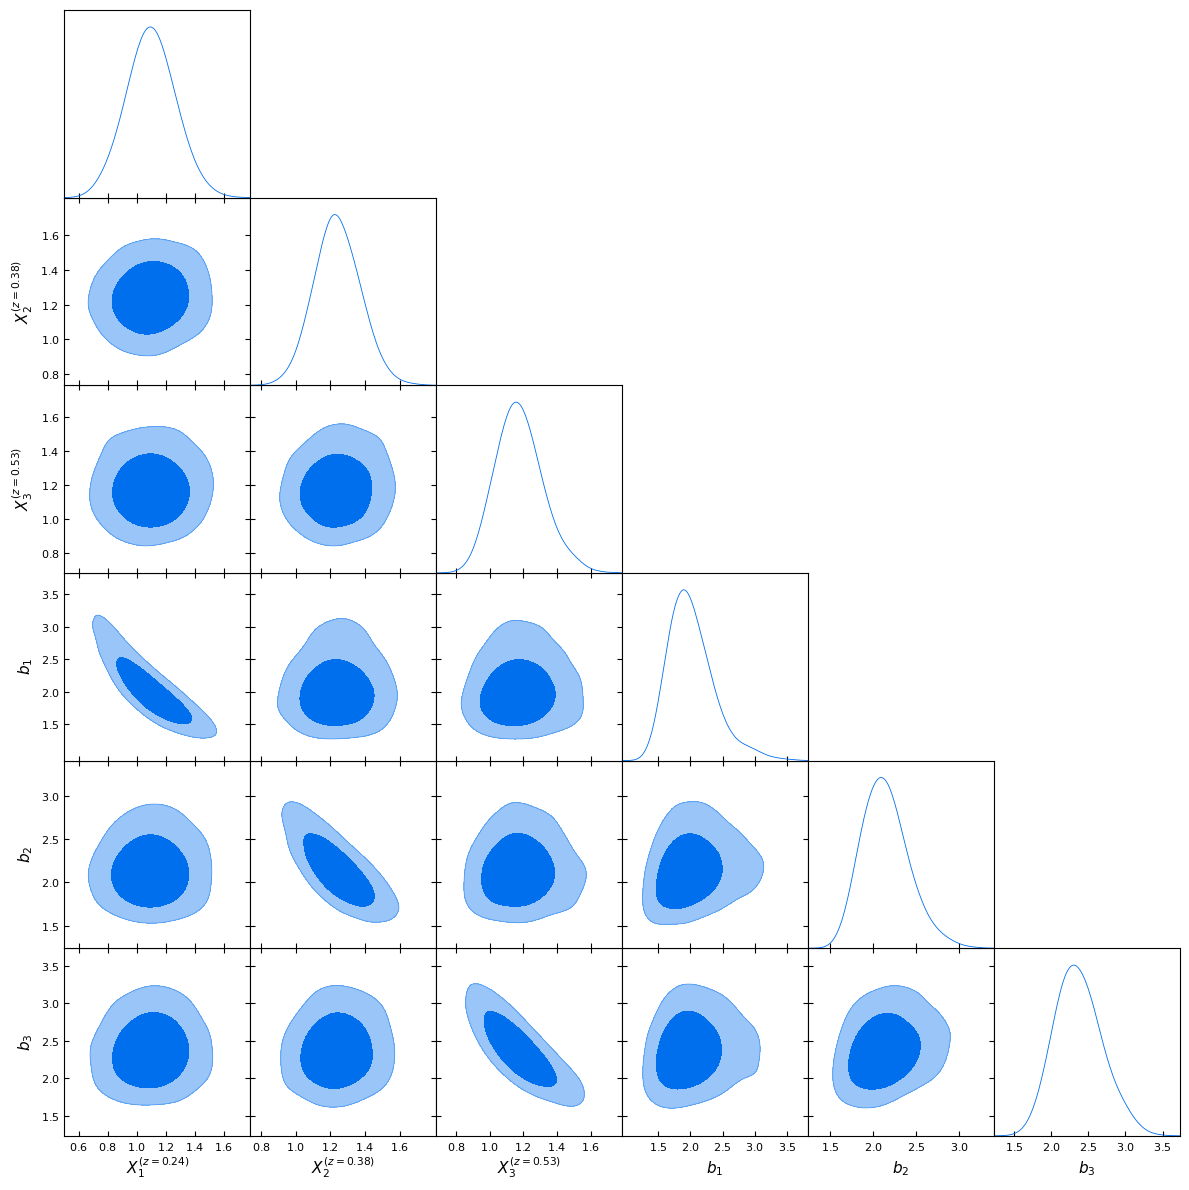

In [6]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    [samples],
    ["X1", "X2", "X3", "b1", "b2", "b3"],
    filled=True
)
g.export("tri_mcmc.png")

In [13]:
corr_params = [
    "S8", "AIA", "dm_0", "dpz_0",
    "X1", "X2", "X3",
    "b1", "b2", "b3"
]

p = samples.getParams()
values = np.column_stack([getattr(p, name) for name in corr_params])
weights = samples.weights
mean = np.average(values, axis=0, weights=weights)
centered = values - mean
cov = ((centered * weights[:, None]).T @ centered / weights.sum())

corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
corr_table = pd.DataFrame(
    corr,
    index=corr_params,
    columns=corr_params
)
display(corr_table.round(2))

,S8,AIA,dm_0,dpz_0,X1,X2,X3,b1,b2,b3
S8,1.00,0.46,-0.13,0.68,-0.30,-0.27,-0.10,-0.04,-0.20,-0.30
AIA,0.46,1.00,0.03,-0.07,-0.20,-0.34,-0.35,0.03,0.10,0.12
dm_0,-0.13,0.03,1.00,-0.01,0.01,-0.03,-0.01,0.02,0.06,0.03
dpz_0,0.68,-0.07,-0.01,1.00,-0.27,-0.04,0.21,0.08,-0.20,-0.39
X1,-0.30,-0.20,0.01,-0.27,1.00,0.08,0.02,-0.85,0.02,0.06
X2,-0.27,-0.34,-0.03,-0.04,0.08,1.00,0.09,0.04,-0.75,0.06
X3,-0.10,-0.35,-0.01,0.21,0.02,0.09,1.00,0.08,0.05,-0.78
b1,-0.04,0.03,0.02,0.08,-0.85,0.04,0.08,1.00,0.18,0.13
b2,-0.20,0.10,0.06,-0.20,0.02,-0.75,0.05,0.18,1.00,0.22
b3,-0.30,0.12,0.03,-0.39,0.06,0.06,-0.78,0.13,0.22,1.00


In [8]:
map_values = {
    "om_m": 0.29044466,
    "sigma8": 0.78272345,
    "S8": 0.78272345 * np.sqrt(0.29044466 / 0.3),
    "AIA": -0.79407104,
    "dm_0": 0.0011879888,
    "dpz_0": -0.029562746,
    "X1": 1.0584525,
    "X2": 1.1665719,
    "X3": 1.2463822
}

comparison_rows = []
for name, map_value in map_values.items():
    par = stats.parWithName(name)

    comparison_rows.append({
        "parameter": name,
        "MAP": map_value,
        "posterior_mean": par.mean,
        "posterior_std": par.err,
        "MAP_minus_mean_in_sigma":
            (map_value - par.mean) / par.err
    })

map_posterior_comparison = pd.DataFrame(comparison_rows)
display(map_posterior_comparison.round(4))

,parameter,MAP,posterior_mean,posterior_std,MAP_minus_mean_in_sigma
0,om_m,0.2904,0.3363,0.0429,-1.0682
1,sigma8,0.7827,0.7059,0.0627,1.2252
2,S8,0.7702,0.7428,0.0466,0.5871
3,AIA,-0.7941,-0.0451,2.8602,-0.2619
4,dm_0,0.0012,0.0003,0.0101,0.0881
5,dpz_0,-0.0296,-0.0574,0.0871,0.3202
6,X1,1.0585,1.0994,0.1739,-0.2356
7,X2,1.1666,1.2409,0.1367,-0.5440
8,X3,1.2464,1.1770,0.1450,0.4787


In [9]:
# ==========================================
# 1. define hsc data 處理的 fuction
# ==========================================
hsc_path = '/home/weichen/cosmo_practice/final_y3_chains'

def load_hsc_chain(file_prefix, label):
    txt_file = os.path.join(hsc_path, f"{file_prefix}.txt")
    names_file = os.path.join(hsc_path, f"{file_prefix}_paramnames.txt")
    
    if not os.path.exists(txt_file):
        print(f"跳過 {label}: can't find {txt_file}")
        return None

    names = []
    if os.path.exists(names_file):
        with open(names_file, 'r') as f:
            names = [line.split()[0] for line in f if line.strip()]
    else:
        with open(txt_file, 'r') as f:
            header = f.readline().strip()
            if header.startswith('#'):
                names = header.lstrip('#').split('\t')
            else:
                return None

    name_map = {
        'cosmological_parameters--omega_m': 'Omm',
        'COSMOLOGICAL_PARAMETERS--S_8': 'S8',
        'omega_m': 'Omm',
        'S_8': 'S8'
    }
    clean_names = [name_map.get(n.strip(), n.strip()) for n in names]

    data = np.loadtxt(txt_file)
    n_cols = data.shape[1]
    n_names = len(clean_names)
    
    weights = None
    if 'weight' in clean_names:
        w_idx = clean_names.index('weight')
        weights = data[:, w_idx]
    
    if n_cols > n_names:
        clean_data = data[:, :n_names]
    else:
        clean_data = data

    samples = MCSamples(
        samples=clean_data, 
        names=clean_names, 
        labels=clean_names,
        weights=weights,
        label=label,
        settings={'ignore_rows': 0.3}
    )
    return samples

print("loading hsc...")
hsc_configs = [
    ['hsc_y3_3x2pt_large_scale', '3x2pt large scale *', 'gray'],
    ['hsc_y3_3x2pt_small_scale', '3x2pt small scale', 'navy'],
    ['hsc_y3_real_cosmic_shear', 'Cosmic shear tomography: Real', 'green'],
    ['hsc_y3_fourier_cosmic_shear', 'Cosmic shear tomography: Fourier', 'firebrick']
]


loading hsc...


Removed 0.3 as burn in
[3x2pt large scale *] params: ['Ombh2', 'Omch2', 'Omde', 'ln10p10As', 'ns', 'b1_0', 'b1_1', 'b1_2', 'alphamag_0', 'alphamag_1', 'alphamag_2', 'dm_0', 'dpz_0', 'AIA', 'alphapsf', 'betapsf', 'Omm', 'sigma8', 'S8', 'signal_dSigma0_0', 'signal_dSigma0_1', 'signal_dSigma0_2', 'signal_dSigma0_3', 'signal_dSigma1_0', 'signal_dSigma1_1', 'signal_dSigma1_2', 'signal_dSigma1_3', 'signal_dSigma1_4', 'signal_dSigma2_0', 'signal_dSigma2_1', 'signal_dSigma2_2', 'signal_dSigma2_3', 'signal_dSigma2_4', 'signal_dSigma2_5', 'signal_dSigma2_6', 'signal_dSigma2_7', 'signal_xip_0', 'signal_xip_1', 'signal_xip_2', 'signal_xip_3', 'signal_xip_4', 'signal_xip_5', 'signal_xip_6', 'signal_xip_7', 'signal_xim_0', 'signal_xim_1', 'signal_xim_2', 'signal_xim_3', 'signal_xim_4', 'signal_xim_5', 'signal_xim_6', 'signal_wp0_0', 'signal_wp0_1', 'signal_wp0_2', 'signal_wp0_3', 'signal_wp0_4', 'signal_wp0_5', 'signal_wp0_6', 'signal_wp0_7', 'signal_wp0_8', 'signal_wp0_9', 'signal_wp0_10', 'signal_

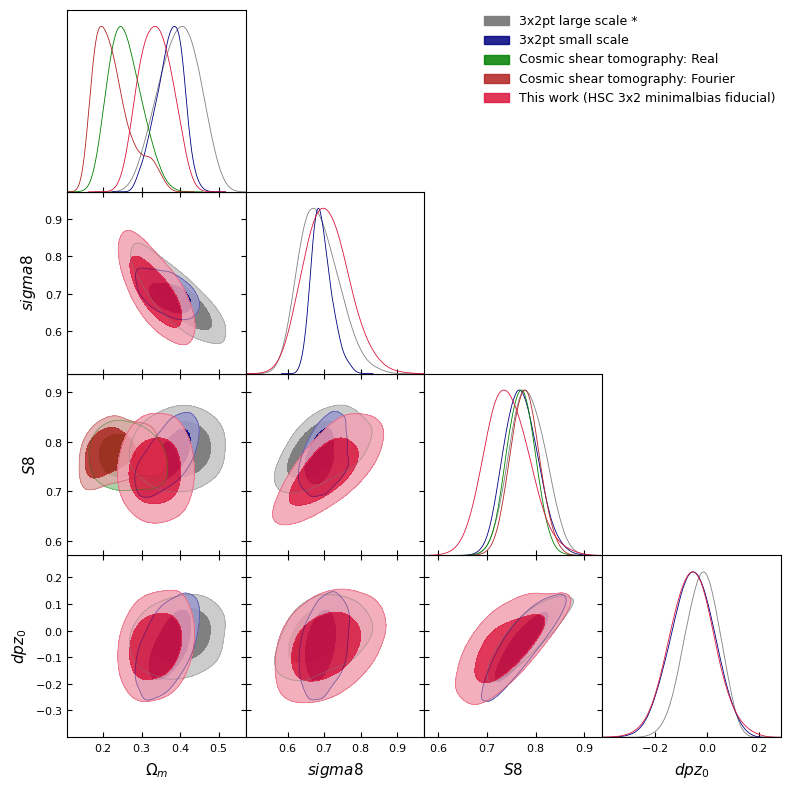

In [10]:
# 疊圖
import getdist.plots as plots

hsc_configs = [
    ['hsc_y3_3x2pt_large_scale', '3x2pt large scale *', 'gray'],
    ['hsc_y3_3x2pt_small_scale', '3x2pt small scale', 'navy'],
    ['hsc_y3_real_cosmic_shear', 'Cosmic shear tomography: Real', 'green'],
    ['hsc_y3_fourier_cosmic_shear', 'Cosmic shear tomography: Fourier', 'firebrick']
]

hsc_samples, hsc_labels, hsc_colors = [], [], []
for prefix, label, color in hsc_configs:
    s = load_hsc_chain(prefix, label)
    if s is None:
        continue
    names = s.getParamNames().list()
    print(f"[{label}] params:", names)

    renames = {}
    if 'Omm' in names:
        renames['Omm'] = 'om_m'
    for cand in ('sigma8', 'sigma_8', 'SIGMA8', 'cosmological_parameters--sigma_8'):
        if cand in names:
            renames[cand] = 'sigma8'
            break
    if renames:
        s.updateRenames(renames)

    hsc_samples.append(s)
    hsc_labels.append(label)
    hsc_colors.append(color)

samples_list = hsc_samples + [samples]
labels = hsc_labels + ['This work (HSC 3x2 minimalbias fiducial)']
colors = hsc_colors + ['crimson']

# 4) triangle plot
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False

g.triangle_plot(
    samples_list,
    ['om_m', 'sigma8', 'S8', 'dpz_0'],
    filled=True,
    contour_colors=colors,
    legend_labels=labels,
    legend_loc='upper right',
)
g.export('tri_compare_hsc.png')

In [12]:
p = samples.getParams()
w = samples.weights

def r(a, b):
    A, B = getattr(p, a), getattr(p, b)
    ca = A - np.average(A, weights=w)
    cb = B - np.average(B, weights=w)
    return np.average(ca*cb, weights=w) / np.sqrt(
        np.average(ca**2, weights=w) * np.average(cb**2, weights=w))

for i in (1, 2, 3):
    print(f'r(X{i}, sigma8) = {r(f"X{i}","sigma8"):+.3f}   '
          f'r(X{i}, om_m) = {r(f"X{i}","om_m"):+.3f}   '
          f'r(X{i}, S8) = {r(f"X{i}","S8"):+.3f}')

r(X1, sigma8) = -0.131   r(X1, om_m) = -0.113   r(X1, S8) = -0.304
r(X2, sigma8) = -0.220   r(X2, om_m) = +0.044   r(X2, S8) = -0.271
r(X3, sigma8) = -0.198   r(X3, om_m) = +0.171   r(X3, S8) = -0.104


In [17]:
def degeneracy_report(root, target_effect=0.08, ignore_rows=0.3,
                      pairs=(("X1","b1",0.2607), ("X2","b2",0.5106), ("X3","b3",0.6264))):
    s = loadMCSamples(root, settings={"ignore_rows": ignore_rows})
    avail = s.getParamNames().list()
    p, w = s.getParams(), s.weights

    is_joint = "A_planck" in avail
    kind = "Joint (with Planck)" if is_joint else "HSC-only"
    print(f"=== {kind} ===  {root.split('/')[-1]}\n")

    def cov(names):
        V = np.column_stack([getattr(p, n) for n in names])
        mu = np.average(V, 0, weights=w)
        Vc = V - mu
        return mu, (Vc * w[:,None]).T @ Vc / w.sum()

    has_s8 = "sigma8" in avail
    rows = []
    for xn, bn, z in pairs:
        if xn not in avail or bn not in avail:
            continue
        names = [xn, bn] + (["sigma8"] if has_s8 else [])
        mu, C = cov(names)
        sx = np.sqrt(C[0,0])
        r_xb = C[0,1] / (sx * np.sqrt(C[1,1]))
        # 對 b 條件化
        s_b = sx * np.sqrt(1 - r_xb**2)
        # 對 (b, sigma8) 同時條件化
        if has_s8:
            Cinv = np.linalg.inv(C)
            s_all = 1/np.sqrt(Cinv[0,0])
            r_x8 = C[0,2] / (sx * np.sqrt(C[2,2]))
        else:
            s_all, r_x8 = s_b, np.nan
        rows.append(dict(param=xn, z=z, mean=mu[0], sigma=sx,
                         r_Xb=r_xb, r_Xs8=r_x8,
                         sig_cond_b=s_b, cost_b=sx/s_b,
                         sig_cond_all=s_all, cost_all=sx/s_all,
                         dev_sigma=(mu[0]-1)/sx))
    df = pd.DataFrame(rows)

    # 合併
    xs = [r["param"] for r in rows]
    _, Cx = cov(xs)
    s_comb = 1/np.sqrt(np.linalg.inv(Cx).sum())
    Rx = Cx/np.sqrt(np.outer(np.diag(Cx), np.diag(Cx)))

    print(f"合併 σ(X) = {s_comb:.4f}   →  對 ΔX={target_effect} 的檢定力 "
          f"{target_effect/s_comb:.2f}σ")
    print(f"X 之間最大 |r| = {max(abs(Rx[i,j]) for i in range(len(xs)) for j in range(i)):.3f}\n")

    if not is_joint and has_s8:
        print("⚠ HSC-only: σ8 為自由參數,X=1 表示『相對 HSC 自己偏好的 σ8』,")
        print("  不是相對 Planck。檢定力欄的 8% 目標值在此脈絡下不直接適用。")
        print("  請看 cost_all(對 b 與 σ8 同時條件化)而非 cost_b。\n")
    else:
        print("✓ Joint: σ8 由 Planck 釘住,X=1 即 Planck ΛCDM 零假設。\n")

    for _, d in df.iterrows():
        if abs(d.r_Xb) > 0.99:
            print(f"⚠ {d.param}: r(X,b)={d.r_Xb:.3f} 極端簡併,X 幾乎不可辨識")
        elif abs(d.r_Xb) > 0.95:
            print(f"· {d.param}: r(X,b)={d.r_Xb:.3f},代價 {d.cost_b:.1f}× "
                  f"(σ {d.sigma:.3f} → 若 b 已知 {d.sig_cond_b:.3f})")
    return df.round(4)

df_hsc = degeneracy_report(chain_root)
display(df_hsc)

=== HSC-only ===  hsc_lens_only_study

合併 σ(X) = 0.0918   →  對 ΔX=0.08 的檢定力 0.87σ
X 之間最大 |r| = 0.092

⚠ HSC-only: σ8 為自由參數,X=1 表示『相對 HSC 自己偏好的 σ8』,
  不是相對 Planck。檢定力欄的 8% 目標值在此脈絡下不直接適用。
  請看 cost_all(對 b 與 σ8 同時條件化)而非 cost_b。



,param,z,mean,sigma,r_Xb,r_Xs8,sig_cond_b,cost_b,sig_cond_all,cost_all,dev_sigma
0,X1,0.2607,1.0994,0.1739,-0.8541,-0.1314,0.0905,1.9226,0.0503,3.4613,0.5716
1,X2,0.5106,1.2409,0.1367,-0.7451,-0.2203,0.0911,1.4994,0.0419,3.2645,1.7629
2,X3,0.6264,1.1770,0.1450,-0.7841,-0.1977,0.0900,1.6111,0.0424,3.4221,1.2205


In [ ]:
'''
planck-hsc joint:

==============================================================================
X-b 簡併代價
==============================================================================
參數      z           X ± σ         r(X,b)    σ(X|b)     cost
------------------------------------------------------------------------------
X1      0.261     1.034 ± 0.150    -0.972     0.035      4.2 (倍)
X2      0.511     1.182 ± 0.122    -0.975     0.027      4.5
X3      0.626     1.145 ± 0.142    -0.970     0.035      4.1
------------------------------------------------------------------------------
σ(X|b) = σ(X)·√(1−r²)   代價 = σ(X)/σ(X|b) = 1/√(1−r²)
條件寬度 = 若 b 已知時的精度;代價 = 不知道 b 所付出的倍數

==============================================================================
檢定力分析 (目標效應 ΔX = 0.08)
==============================================================================
參數       偏離1        現況顯著性     若 b 已知
------------------------------------------------------------------------------
X1        +0.23σ         0.53σ         2.27σ
X2        +1.49σ         0.65σ         2.91σ
X3        +1.02σ         0.56σ         2.32σ
------------------------------------------------------------------------------
合併                     1.00σ
合併後 σ = 0.0799

==============================================================================
X 之間的相關係數
==============================================================================
            X1        X2        X3
X1         1.000     0.030     0.015
X2         0.030     1.000     0.002
X3         0.015     0.002     1.000

最大非對角 |r| = 0.030

==============================================================================
線性趨勢與零假設檢定
==============================================================================
dX/dz      = +0.352 ± 0.552   (+0.64σ)
χ²(X=1)    = 3.31  (3 dof)

註: 此處用點估計做事後合併,忽略了 X 之間的殘餘相關。
'''
'''
(cobaya) [wcshih@kawas cosmo_practice]$ python /theory/home/wcshih/cosmo_practice/scripts/test.py
X1: dm_0 -0.061   dpz_0 -0.060   sigma8 -0.082   b1 -0.972
X2: dm_0 -0.030   dpz_0 +0.129   sigma8 -0.008   b2 -0.975
X3: dm_0 +0.058   dpz_0 +0.351   sigma8 -0.020   b3 -0.970
dm_0     0.0001
logA     3.0404
X1       0.9860
X2       1.1477
X3       1.1052
b1       1.9297
b2       2.0652
b3       2.2078
sigma8   0.8088
r(X1,X2) = +0.034
r(X1,X3) = +0.015
r(X2,X3) = +0.003
X1 = 1.034 ± 0.149
X2 = 1.182 ± 0.123
X3 = 1.145 ± 0.142
'''